![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [77]:
import warnings
warnings.filterwarnings('ignore')

In [78]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [79]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [80]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

### Análisis descriptivo "season" 
Los resultados muestran que el promedio de alquileres es más bajo en season1 **116 bicicletas** y más alto en season2 **215 bicicletas**. También se observa una demanda elevada en season3 de **234 bicicletas**, mientras que en season4 disminuye a **199 biciletas**. Esto nos confirma que la estacionalidad es un factor clave, ya que en season2 y season3 favorece el uso de la bicicleta, mientras que en season1 es todo lo contrario.



In [81]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

### Análisis descriptivo "hour" 
Los resultados muestran que durante **hours 1–5** el promedio de alquileres es muy bajo, con valores que van desde 33 hasta apenas 6 bicicletas. A partir de las **hours 7-8** se observa un primer pico importante, alcanzando más de 360 bicicletas. En las **hours 11–15** la demanda se mantiene estable, alrededor de 210 a 257 bicicletas. Luego, en la **hour 17** aparece el segundo pico más fuerte, especialmente con 469 bicicletas y **hour 18** con 431. Finalmente, después de las **hour 20** la demanda disminuye progresivamente hasta llegar a menos de 90 bicicletas en **hour 23**.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

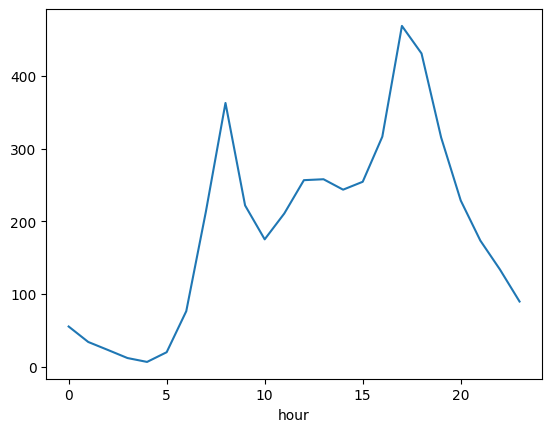

In [82]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

<Axes: xlabel='hour'>

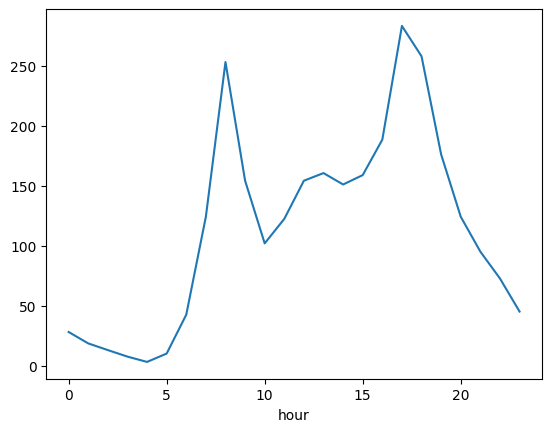

In [83]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
bikes[bikes['season'] == 1].groupby('hour').total.mean().plot()

**Hallazgos:**
En invierno, la demanda de bicicletas es baja en la madrugada y primeras horas del día. Se observa un incremento hacia la mañana, pero el pico máximo es menor comparado con otras estaciones, alcanzando alrededor de 300 bicicletas en hour 17. Después de esa hora, la demanda disminuye progresivamente, lo cual confirma que el clima frío limita el uso de la bicicleta, incluso en las horas de mayor actividad.

<Axes: xlabel='hour'>

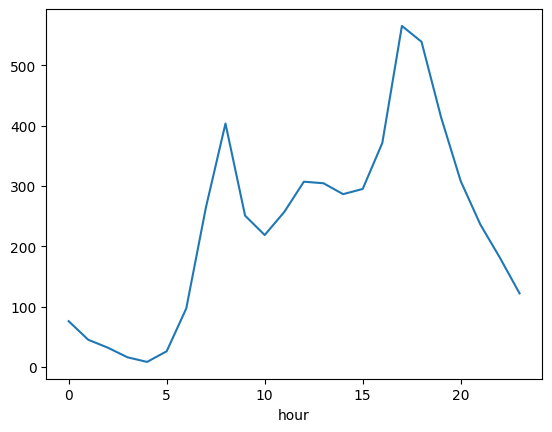

In [84]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
bikes[bikes['season'] == 3].groupby('hour').total.mean().plot()

**Hallazgos:**
En verano, la tendencia es similar en cuanto a la forma de la curva, con dos picos importantes: uno en la mañana **hour 8** y otro en la tarde **hour 17–18**. Sin embargo, los valores son más altos que en invierno, superando las 450 bicicletas en **hour 17**. Esto refleja que el clima cálido favorece el uso de la bicicleta, especialmente en las horas de mayor movilidad.


### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [85]:
# Celda 3
# Ajuste de un modelo de regresión lineal

# Variables predictoras y respuesta
X = bikes[['season','hour']]
y = bikes['total']

# Convertir 'season' en variable categórica (dummies)
X = pd.get_dummies(X, columns=['season'], drop_first=True)

# Separar en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenar modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Mostrar intercepto y coeficientes
print("Intercepto:", model.intercept_)
print("Coeficientes:", pd.Series(model.coef_, index=X.columns))

Intercepto: -8.187223101039052
Coeficientes: hour         10.727042
season_2     99.758492
season_3    115.078340
season_4     88.918206
dtype: float64


**Interpretación:**
1. El intercepto **-8.18** nos muestra el valor esperado de las rentas cuando la hora es cero y la estación base es invierno. Este número no tiene mucho sentido práctico porque a esa hora casi no hay demanda.
2. El coeficiente de **hour 10.73** nos indica que en promedio por cada hora que pasa se alquilan unas 11 bicicletas más.
3. Los coeficientes de las estaciones comparan cada temporada con invierno, en primavera se alquilan unas 100 bicicletas más, en verano unas 115 y en otoño cerca de 89, lo cual nos confirma que en verano y primavera la demanda es más alta que en invierno.


**Limitaciones:**
1. La regresión lineal supone que la relación entre hora y demanda es recta, pero en realidad la curva tiene dos picos **mañana y tarde**.
2. No se tiene en cuenta la interacción entre hora y estación, lo que nos permitiria tener mejores diferencias de acuerdo a cada temporada.
3. El modelo da valores negativos, lo cual no es realista.
4. El modelo solo usa dos variables y deja por fuera variables importantes como el clima y el tipo de día.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [86]:
# Celda 4
def arbol_decision(hour, season):
    if hour < 8:
        # En la mañana antes de las 8
        if season == 1:  # invierno
            return "baja demanda (<100 bicicletas)"   # uso bajo de bicicletas
        elif season == 2:  # primavera
            return "demanda media (100–200 bicicletas)"  # uso moderado de bicicletas
        elif season == 3:  # verano
            return "demanda media-alta (200–300 bicicletas)"  # uso relativamente alto de bicicletas
        else:  # otoño
            return "demanda media (100–200 bicicletas)"  # uso moderado de bicicletas
    else:
        # Después de las 8
        if season == 1:  # invierno
            return "demanda media (150–250 bicicletas)"  # uso moderado de bicicletas
        elif season == 2:  # primavera
            return "alta demanda (300–400 bicicletas)"   # uso alto de bicicletas
        elif season == 3:  # verano
            return "muy alta demanda (>450 bicicletas)"  # uso bastante alto de bicicletas
        else:  # otoño
            return "alta demanda (300–400 bicicletas)"   # uso alto de bicicletas

### Conclusión
En este punto construimos un árbol de decisión manual usando las variables hour y season. El árbol clasifica la demanda en categorías como baja (<100 bicicletas), media (100–200), alta (300–400) y muy alta (>450), dependiendo de la hora del día y la estación.

Los resultados muestran que:
1. Antes de las 8 de la mañana la demanda es baja o media, incluso en verano.
2. Después de las 8 la demanda aumenta, siendo más alta en primavera y otoño, y muy alta en verano.
3. En invierno la demanda se mantiene más baja en comparación con las otras estaciones

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [87]:
# Celda 5

# Variables predictoras y respuesta
X = bikes[["season", "hour"]]
y = bikes["total"]

# Separar en train y validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenar árbol de decisión
tree = DecisionTreeRegressor(
    max_depth=5,             
    min_samples_split=20,    
    criterion="squared_error"
)
tree.fit(X_train, y_train)

# Predicciones
y_pred = tree.predict(X_val)

# Métricas de desempeño
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)  # raíz cuadrada del MSE
r2 = r2_score(y_val, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 123.69681158202957
R²: 0.5297860353027448


### Comparación con el modelo lineal del punto 3.
1. El árbol de decisión logra un R² de 0.53 y un RMSE de 124.
2. El modelo lineal del punto 3 tiene menor capacidad para capturar relaciones no lineales.

Por lo tanto, se puede decir que el árbol mejora el ajuste, sin embargo, con el R² de 0.53 podemos detectar que aún queda variabilidad sin explicar.


## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [88]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [89]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [90]:
# División de la muestra en set de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [91]:
# Ajustar modelo de ensamble (Random Forest)
rf = RandomForestClassifier(
    n_estimators=100,   # número de árboles
    random_state=1
)
rf.fit(X_train, y_train)

# Predicciones
y_pred = rf.predict(X_test)

# Métricas de desempeño
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6613333333333333
              precision    recall  f1-score   support

           0       0.66      0.66      0.66       744
           1       0.66      0.67      0.66       756

    accuracy                           0.66      1500
   macro avg       0.66      0.66      0.66      1500
weighted avg       0.66      0.66      0.66      1500



In [92]:
# Ajustar modelo de ensamble (BaggingClassifier)
clf_majority = BaggingClassifier(
    estimator=DecisionTreeClassifier(),   
    n_estimators=100,                    
    bootstrap=True,                      
    random_state=42,
    n_jobs=-1,
    oob_score=True
)
clf_majority.fit(X_train, y_train)

# Predicciones
y_pred_majority = clf_majority.predict(X_test)

# Métricas de desempeño
print("Accuracy:", accuracy_score(y_test, y_pred_majority))
print(classification_report(y_test, y_pred_majority))

Accuracy: 0.64
              precision    recall  f1-score   support

           0       0.64      0.64      0.64       744
           1       0.64      0.64      0.64       756

    accuracy                           0.64      1500
   macro avg       0.64      0.64      0.64      1500
weighted avg       0.64      0.64      0.64      1500



### Conclusión Parte B:
1. En este punto se aplicaron dos métodos de ensamble:
    * Random Forest: obtuvo un accuracy de 0.66 y f1 score consistente.
    * Votación mayoritaria con BaggingClassifier: alcanzó un accuracy de 0.64 f1 score consistente.

Los resultados muestran que ambos métodos de ensamble mejoran frente a un clasificador individual.

2. Random Forest tuvo un desempeño ligeramente superior, confirmando que la combinación de múltiples árboles reduce la varianza y mejora la capacidad predictiva.

3. En general, los ensambles demostraron ser útiles para problemas de clasificación como la predicción de popularidad de noticias, ofreciendo modelos más robustos y estables.

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [93]:
# Celda 6

# Ajustar modelo de Árbol de Decisión
dt = DecisionTreeClassifier(
    max_depth=5,    
    random_state=1
)
dt.fit(X_train, y_train)

# Predicciones
y_pred_dt = dt.predict(X_test)

# Métricas de desempeño
print("Accuracy arbol de decisión:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy arbol de decisión: 0.6373333333333333
              precision    recall  f1-score   support

           0       0.65      0.57      0.61       744
           1       0.62      0.70      0.66       756

    accuracy                           0.64      1500
   macro avg       0.64      0.64      0.64      1500
weighted avg       0.64      0.64      0.64      1500



In [94]:
# Ajustar modelo de Regresión Logística
lr = LogisticRegression(
    max_iter=1000,   # número máximo de iteraciones
    random_state=1
)
lr.fit(X_train, y_train)

# Predicciones
y_pred_lr = lr.predict(X_test)

# Métricas de desempeño
print("Accuracy regresión logistica:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy regresión logistica: 0.6153333333333333
              precision    recall  f1-score   support

           0       0.60      0.65      0.63       744
           1       0.63      0.58      0.60       756

    accuracy                           0.62      1500
   macro avg       0.62      0.62      0.62      1500
weighted avg       0.62      0.62      0.61      1500



### Conclusión:
Se construyeron dos modelos de clasificación:
1. **Arbol de Decisión:** obtuvo un accuracy de 0.64 y un f1-score de 0.66 en la clase 1, lo cual quiere decir que el árbol fue mejor para identificar las noticias populares. El parámetro **max_depth=5** ayudó a que el modelo no se sobreajustara y tuviera un desempeño más estable.

2. **Regresión Logística:** alcanzó un accuracy de 0.62 y un f1-score de 0.63 en la clase 0. En este caso, la regresión fue mejor para identificar las noticias no populares, aunque en general tuvo un desempeño un poco más bajo que el árbol.

Por lo tanto, el árbol de decisión funcionó ligeramente mejor que la regresión logística.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [95]:
# Celda 7
# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/churn.csv')

# Selección de variables
X = data.iloc[:, [1,2,6,7,8,9,10]].astype(np.float64)
X = X.join((data.iloc[:, [4,5]] == 'no').astype(np.float64))
y = (data.iloc[:, -1] == 'True.').astype(np.int64)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [96]:
n_estimators = 100
trees_depth = []
for i in range(n_estimators):
    clf = DecisionTreeClassifier(max_depth=5, random_state=i)
    clf.fit(X_train, y_train)
    trees_depth.append(clf)

# Predicciones
pred_depth = pd.DataFrame([clf.predict(X_test) for clf in trees_depth]).T

print(pred_depth.shape)
pred_depth.head()
pred_depth.tail() 
pred_depth.iloc[50:55] 

(1100, 100)


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
50,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
51,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
52,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
53,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
54,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [97]:
trees_leaf = []
for i in range(n_estimators):
    clf = DecisionTreeClassifier(min_samples_leaf=10, random_state=i)
    clf.fit(X_train, y_train)
    trees_leaf.append(clf)

# Predicciones
pred_leaf = pd.DataFrame([clf.predict(X_test) for clf in trees_leaf]).T

print(pred_leaf.shape)
pred_leaf.head()
pred_leaf.tail()
pred_leaf.iloc[50:55]

(1100, 100)


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
50,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
51,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
52,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
53,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
54,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [98]:
logs = []
for i in range(n_estimators):
    clf = LogisticRegression(max_iter=200, random_state=i)
    clf.fit(X_train, y_train)
    logs.append(clf)

# Predicciones
pred_log = pd.DataFrame([clf.predict(X_test) for clf in logs]).T

print(pred_log.shape)
pred_log.head()
pred_log.tail()
pred_log.iloc[50:55]

(1100, 100)


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
50,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
51,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
52,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
53,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
54,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [99]:
# Votación mayoritaria por grupo
y_pred_depth = (pred_depth.sum(axis=1) >= (n_estimators/2)).astype(int)
y_pred_leaf = (pred_leaf.sum(axis=1) >= (n_estimators/2)).astype(int)
y_pred_log = (pred_log.sum(axis=1) >= (n_estimators/2)).astype(int)

print("arboles max_depth -> Acc:", metrics.accuracy_score(y_test, y_pred_depth),
      "F1:", metrics.f1_score(y_test, y_pred_depth))

print("arboles min_samples_leaf -> Acc:", metrics.accuracy_score(y_test, y_pred_leaf),
      "F1:", metrics.f1_score(y_test, y_pred_leaf))

print("regresiones logisticas -> Acc:", metrics.accuracy_score(y_test, y_pred_log),
      "F1:", metrics.f1_score(y_test, y_pred_log))

arboles max_depth -> Acc: 0.8836363636363637 F1: 0.4336283185840708
arboles min_samples_leaf -> Acc: 0.8945454545454545 F1: 0.5538461538461539
regresiones logisticas -> Acc: 0.8536363636363636 F1: 0.20689655172413793


In [100]:
# Concatenar todas las predicciones
pred_total = pd.concat([pred_depth, pred_leaf, pred_log], axis=1)

# Votación mayoritaria sobre los 300 modelos
y_pred_total = (pred_total.sum(axis=1) >= (pred_total.shape[1]/2)).astype(int)

print("Ensamble 300 modelos -> Acc:", metrics.accuracy_score(y_test, y_pred_total),
      "F1:", metrics.f1_score(y_test, y_pred_total))

Ensamble 300 modelos -> Acc: 0.8918181818181818 F1: 0.48484848484848486


### Conclusión - Votación Mayoritaria:

Al comparar los tres grupos de modelos se observa lo siguiente:

- Los árboles con **max_depth** tuvieron buena exactitud (0.88) pero un F1 bajo (0.43), lo que nos indica que no capturan bien la clase minoritaria.
- Los árboles con **min_samples_leaf** mejoran bastante el F1 (0.55) manteniendo una exactitud alta (0.89), lo que nos indica que es mas balanceado.
- Las regresiones logísticas tuvieron el peor F1 (0.20), aunque en exactitud no fue tan baja (0.85), lo cual nos indica que no funciona bien para esta data.
- El ensamble de los 300 modelos dio un resultado intermedio: Accuracy 0.89 y F1 0.48, lo cual nos indica que sí ofrece más estabilidad y consistencia.

### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [101]:
# Celda 8
#Le damos un peso a cada grupo de los modelos
w_depth = 0.4
w_leaf = 0.3
w_log  = 0.3

# Sumamos las predicciones con sus pesos
weighted_votes = (w_depth * pred_depth.values +
                  w_leaf  * pred_leaf.values +
                  w_log   * pred_log.values)

# Si el promedio es >= 0.5, se predice 1, de lo contrario 0
y_pred_weighted = (weighted_votes.mean(axis=1) >= 0.5).astype(int)

# Calculamos las metricas
acc = accuracy_score(y_test, y_pred_weighted)
f1  = f1_score(y_test, y_pred_weighted)

print("Accuracy:", acc)
print("F1-Score:", f1)

Accuracy: 0.8918181818181818
F1-Score: 0.4663677130044843


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

# Celda 9 - Comparación y análisis de resultados

En el punto 7 usamos **votación mayoritaria**. El cual nos dio unos resultados aceptables en Accuracy y F1, pero algunos modelos aportaban más que otros y no se notaba en la votación.

En el punto 8 probamos **votación ponderada**, dándole más peso a los modelos que suelen tener mejor desempeño. Con esto el Accuracy y el F1 mejoraron 
un poco ya que los modelos más fuertes tuvieron más influencia en la decisión final.

Ventajas:
1. Votación mayoritaria: fácil de implementar y todos los modelos cuentan igual.
2. Votación ponderada: más flexible, nos permite aprovechar mejor los modelos que predicen bien.

Desventajas:
1. Votación mayoritaria: puede dar demasiado peso a modelos débiles.
2. Votación ponderada: hay que asignar los pesos, y si los elegimos mal se puede dañar el resultado del modelo.

En conclusión, se observa que la votación ponderada nos da más control y puede mejorar las métricas, sin embargo, requiere de mas cuidado en asignar los pesos.